In [ ]:
!pip install torchinfo

In [ ]:
import os
import sys
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm.notebook import tqdm
import zipfile
import shutil


In [ ]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("pandas version:", pd.__version__)
print("PIL version:", PIL.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

Platform: linux
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
---
pandas version: 2.2.2
PIL version: 11.3.0
torch version: 2.11.0+cpu
torchvision version: 0.26.0+cpu


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
zip_path = "/content/drive/MyDrive/wildlife.zip"

extraction_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extraction_path)

print("Image Dataset extracted successfully")

Image Dataset extracted successfully


In [ ]:
df = pd.read_csv("/content/dataset/train_labels.csv")
df.head()

,id,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ZJ000001,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,ZJ000002,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ZJ000003,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,ZJ000004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
source_dir = "dataset/train_features"

dest_dir = "dataset/organized_features"


classes = df.columns[1:]

for animal_class in classes:
    os.makedirs(os.path.join(dest_dir, animal_class), exist_ok=True)

animal_mapping = df.set_index('id').idxmax(axis=1)

print(f"Creating folders and sorting {len(animal_mapping)} images...")

# Iterate through the mapping and physically move the images
for img_id, animal_class in tqdm(animal_mapping.items(), total=len(animal_mapping)):

    src_path = os.path.join(source_dir, f"{img_id}.jpg")
    dst_path = os.path.join(dest_dir, animal_class, f"{img_id}.jpg")

    if os.path.exists(src_path):

        shutil.move(src_path, dst_path)

print(" Organized Classes Executed")

Creating folders and sorting 16488 images...


  0%|          | 0/16488 [00:00<?, ?it/s]

 Organized Classes Executed


In [ ]:
class ConvertToRGB:
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

In [ ]:
transform = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]
)

In [ ]:
train_dir = os.path.join("dataset","organized_features")

print("Will read data from", train_dir)

Will read data from dataset/organized_features


In [ ]:
dataset = datasets.ImageFolder(root=train_dir, transform=transform)

In [ ]:
classes = os.listdir(train_dir)
print(f"Classes: {classes}")

Classes: ['blank', 'antelope_duiker', 'rodent', 'hog', 'bird', 'monkey_prosimian', 'civet_genet', 'leopard']


In [ ]:
print("Tensor shape for one image:")
print(dataset[0][0].shape)

Tensor shape for one image:
torch.Size([3, 224, 224])


In [ ]:
batch_size = 32
dataset_loader = DataLoader(dataset, batch_size=batch_size)

# Get one batch
first_batch = next(iter(dataset_loader))

print(f"Shape of one batch: {first_batch[0].shape}")
print(f"Shape of labels: {first_batch[1].shape}")

Shape of one batch: torch.Size([32, 3, 224, 224])
Shape of labels: torch.Size([32])


# Preparing Our Data

In [ ]:
def get_mean_std(loader):
    """Computes the mean and standard deviation of image data.

    Input: a `DataLoader` producing tensors of shape [batch_size, channels, pixels_x, pixels_y]
    Output: the mean of each channel as a tensor, the standard deviation of each channel as a tensor
            formatted as a tuple (means[channels], std[channels])"""

    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    for data, _ in tqdm(loader, desc="Computing mean and std", leave=False):
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean**2) ** 0.5

    return mean, std

In [ ]:
mean, std = get_mean_std(dataset_loader)

print(f"Mean: {mean}")
print(f"Standard deviation: {std}")

Computing mean and std:   0%|          | 0/516 [00:00<?, ?it/s]

Mean: tensor([0.4788, 0.4925, 0.4833])
Standard deviation: tensor([0.2541, 0.2470, 0.2501])


In [ ]:
transform_norm = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ]
)

In [ ]:
norm_dataset = datasets.ImageFolder(root= train_dir, transform=transform_norm)

norm_loader = DataLoader(norm_dataset, batch_size=batch_size)

In [ ]:
norm_mean, norm_std = get_mean_std(norm_loader)

print(f"Mean: {norm_mean}")
print(f"Standard deviation: {norm_std}")

Computing mean and std:   0%|          | 0/516 [00:00<?, ?it/s]

Mean: tensor([-2.2570e-07, -7.9987e-07, -1.4907e-07])
Standard deviation: tensor([1.0000, 1.0000, 1.0000])


# Train and Validation Split

In [ ]:
train_dataset, val_dataset = random_split(norm_dataset, [0.8, 0.2])

length_train = len(train_dataset)
length_val = len(val_dataset)
length_dataset = len(norm_dataset)
percent_train = np.round(100 * length_train / length_dataset, 2)
percent_val = np.round(100 * length_val / length_dataset, 2)

print(f"Train data is {percent_train}% of full data")
print(f"Validation data is {percent_val}% of full data")

Train data is 80.0% of full data
Validation data is 20.0% of full data


# Train Test Distribution

In [ ]:
def class_counts(dataset):
    c = Counter(x[1] for x in tqdm(dataset))
    class_to_index = dataset.dataset.class_to_idx
    return pd.Series({cat: c[idx] for cat, idx in class_to_index.items()})

In [ ]:
train_class_distributions = class_counts(train_dataset)

train_class_distributions

  0%|          | 0/13191 [00:00<?, ?it/s]

,0
antelope_duiker,1965
bird,1303
blank,1756
civet_genet,1982
hog,781
leopard,1786
monkey_prosimian,2008
rodent,1610


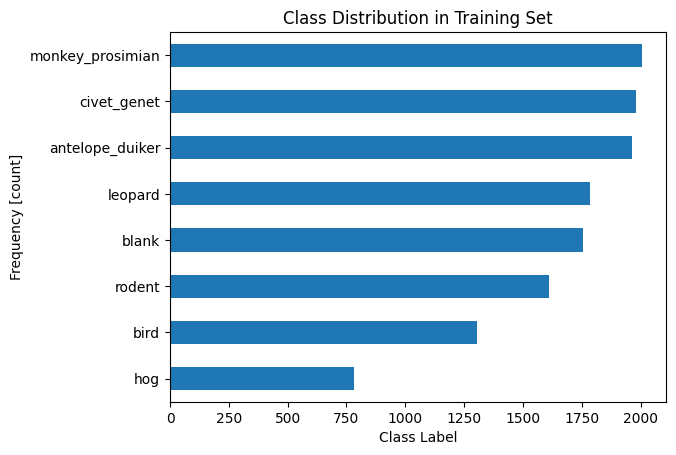

In [ ]:
train_class_distributions.sort_values().plot(kind="barh")

plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Class Distribution in Training Set");

In [ ]:
validation_class_distributions = class_counts(val_dataset)

print(validation_class_distributions)

  0%|          | 0/3297 [00:00<?, ?it/s]

antelope_duiker     509
bird                338
blank               457
civet_genet         441
hog                 197
leopard             468
monkey_prosimian    484
rodent              403
dtype: int64


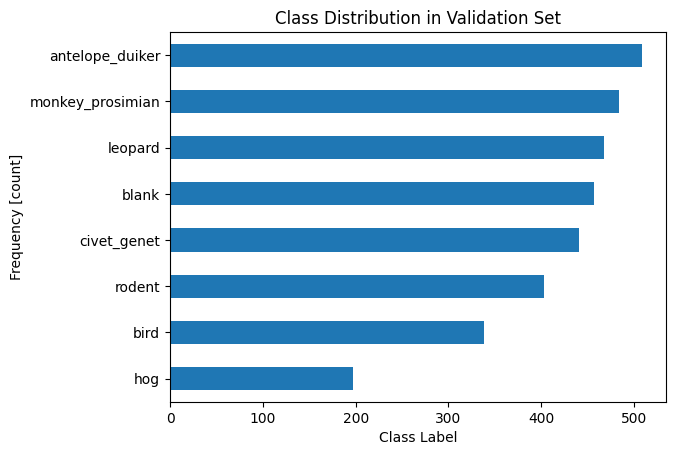

In [ ]:
validation_class_distributions.sort_values().plot(kind="barh")


plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Class Distribution in Validation Set");

In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)

val_loader = DataLoader(val_dataset,batch_size=batch_size)

single_batch = next(iter(train_loader))[0]
print(f"Shape of one batch: {single_batch.shape}")

Shape of one batch: torch.Size([32, 3, 224, 224])


# Neural Network Architecture

In [ ]:
model_seq = torch.nn.Sequential()

## First Convolutional Layer

In [ ]:
conv1 = torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding=1)
model_seq.append(conv1)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

# Define A Test Batch

In [ ]:
test_batch = next(iter(train_loader))[0]

batch_shape = test_batch.shape

print(f"Batch shape: {batch_shape}")

Batch shape: torch.Size([32, 3, 224, 224])


# Test First Convolutional Layer Output

In [ ]:
first_step_out = model_seq(test_batch)

first_step_shape = first_step_out.shape

print(f"Shape after first convolution layer: {first_step_shape}")

Shape after first convolution layer: torch.Size([32, 16, 224, 224])


# Add ReLU Activation Layer 1

In [ ]:
model_seq.append(torch.nn.ReLU())

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
)

# Add MaxPooling Layer 1

In [ ]:
max_pool1 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)
model_seq.append(max_pool1)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
)

# Test The Network After Max Pooling Layer Output

In [ ]:
max_pool_out = model_seq(test_batch)
max_pool_shape = max_pool_out.shape

print(f"Shape after first max pool: {max_pool_shape}")

Shape after first max pool: torch.Size([32, 16, 112, 112])


# Add Convolutional Layer 2



In [ ]:
second_conv = torch.nn.Conv2d(in_channels=16,out_channels=32,kernel_size=(3,3), padding=1)
second_pool = torch.nn.MaxPool2d(kernel_size=(2,2), stride=2)
model_seq.append(second_conv)
model_seq.append(torch.nn.ReLU())
model_seq.append(second_pool)


Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
)

# Test After MaxPooling Of Convolutional Layer 2

In [ ]:
second_set_out = model_seq(test_batch)
second_set_shape = second_set_out.shape

print(f"Shape after second max pool: {second_set_shape}")

Shape after second max pool: torch.Size([32, 32, 56, 56])


# Add Convolutional Layer 3


In [ ]:
conv3 = torch.nn.Conv2d(32, 64, 3, padding=1)
max_pool3 = torch.nn.MaxPool2d(2)
model_seq.append(conv3)
model_seq.append(torch.nn.ReLU())
model_seq.append(max_pool3)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

# Testing After MaxPooling Of Convolutional Layer 3

In [ ]:
third_set_out = model_seq(test_batch)
third_set_shape = third_set_out.shape

print(f"Shape after third max pool: {third_set_shape}")

Shape after third max pool: torch.Size([32, 64, 28, 28])


# Flattening

In [ ]:
model_seq.append(torch.nn.Flatten())

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
)

# Test After Flattening the Output

In [ ]:
flat_out = model_seq(test_batch)
flat_shape = flat_out.shape

print(f"Shape after flattening: {flat_shape}")

Shape after flattening: torch.Size([32, 50176])


In [ ]:
linear1 = torch.nn.Linear(in_features=50176, out_features=500)

model_seq.append(linear1)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=50176, out_features=500, bias=True)
)

In [ ]:
model_seq.append(torch.nn.ReLU())

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=50176, out_features=500, bias=True)
  (11): ReLU()
)

In [ ]:
linear_out = model_seq(test_batch)
linear_shape = linear_out.shape

print(f"Shape after linear layer: {linear_shape}")

Shape after linear layer: torch.Size([32, 500])


# Output Layer

In [ ]:
output_layer = torch.nn.Linear(in_features=500, out_features=8)

model_seq.append(output_layer)


Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=50176, out_features=500, bias=True)
  (11): ReLU()
  (12): Linear(in_features=500, out_features=8, bias=True)
)

In [ ]:
model_seq(test_batch).shape

torch.Size([32, 8])

# Training The Model

In [ ]:
model = torch.nn.Sequential()

conv1 = torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding=1)
max_pool1 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)
model.append(conv1)
model.append(torch.nn.ReLU())
model.append(max_pool1)

conv2 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding=1)
max_pool2 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)
model.append(conv2)
model.append(torch.nn.ReLU())
model.append(max_pool2)

conv3 = torch.nn.Conv2d(32, 64, 3, padding=1)
max_pool3 = torch.nn.MaxPool2d(2)
model.append(conv3)
model.append(torch.nn.ReLU())
model.append(max_pool3)

model.append(torch.nn.Flatten())
model.append(torch.nn.Dropout())

linear1 = torch.nn.Linear(in_features=50176, out_features=500)
model.append(linear1)
model.append(torch.nn.ReLU())
model.append(torch.nn.Dropout())

output_layer = torch.nn.Linear(500, 8)
model.append(output_layer)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Dropout(p=0.5, inplace=False)
  (11): Linear(in_features=50176, out_features=500, bias=True)
  (12): ReLU()
  (13): Dropout(p=0.5, inplace=False)
  (14): Linear(in_features=500, out_features=8, bias=True)
)

In [ ]:
height, width = 224, 224
summary(model, input_size=(batch_size, 3, height, width))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 8]                   --
├─Conv2d: 1-1                            [32, 16, 224, 224]        448
├─ReLU: 1-2                              [32, 16, 224, 224]        --
├─MaxPool2d: 1-3                         [32, 16, 112, 112]        --
├─Conv2d: 1-4                            [32, 32, 112, 112]        4,640
├─ReLU: 1-5                              [32, 32, 112, 112]        --
├─MaxPool2d: 1-6                         [32, 32, 56, 56]          --
├─Conv2d: 1-7                            [32, 64, 56, 56]          18,496
├─ReLU: 1-8                              [32, 64, 56, 56]          --
├─MaxPool2d: 1-9                         [32, 64, 28, 28]          --
├─Flatten: 1-10                          [32, 50176]               --
├─Dropout: 1-11                          [32, 50176]               --
├─Linear: 1-12                           [32, 500]                 25,088,500

In [ ]:
from training import predict, train

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.to(device)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Dropout(p=0.5, inplace=False)
  (11): Linear(in_features=50176, out_features=500, bias=True)
  (12): ReLU()
  (13): Dropout(p=0.5, inplace=False)
  (14): Linear(in_features=500, out_features=8, bias=True)
)

In [ ]:
train(model,optimizer,loss_fn,train_loader,val_loader,epochs=10,device="cpu")

Training:   0%|          | 0/413 [00:00<?, ?it/s]

Scoring:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch: 1, Training Loss: 1.38, Validation Loss: 0.99, Validation accuracy = 0.65


Training:   0%|          | 0/413 [00:00<?, ?it/s]

Scoring:   0%|          | 0/104 [00:00<?, ?it/s]

...

Scoring:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch: 9, Training Loss: 0.27, Validation Loss: 0.53, Validation accuracy = 0.86


Training:   0%|          | 0/413 [00:00<?, ?it/s]

Scoring:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch: 10, Training Loss: 0.24, Validation Loss: 0.49, Validation accuracy = 0.86


In [52]:
probabilities = predict(model, val_loader, device)
predictions = torch.argmax(probabilities,dim=1)

Predicting:   0%|          | 0/104 [00:00<?, ?it/s]

In [53]:
targets = []

for _, labels in tqdm(val_loader):
    targets.extend(labels.tolist())

  0%|          | 0/104 [00:00<?, ?it/s]

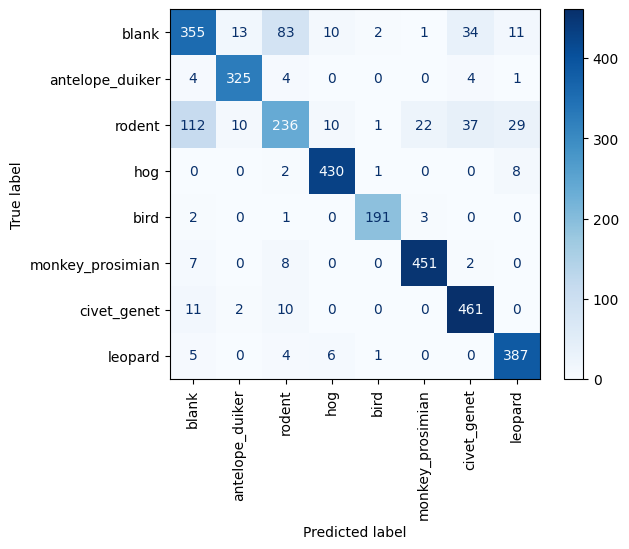

In [54]:
cm = confusion_matrix(targets, predictions.cpu())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
plt.show();

# ID Mapping CSV

In [68]:
# The root folder for your data
dataset_root = "dataset"

# The path to your CSV file
csv_location = os.path.join(dataset_root, "test_features.csv")

# Read the CSV
df_ids = pd.read_csv(csv_location)
df_ids.head()

,id,filepath,site
0,ZJ016488,test_features/ZJ016488.jpg,S0082
1,ZJ016489,test_features/ZJ016489.jpg,S0040
2,ZJ016490,test_features/ZJ016490.jpg,S0040
3,ZJ016491,test_features/ZJ016491.jpg,S0041
4,ZJ016492,test_features/ZJ016492.jpg,S0040


In [69]:
model.to(device)


def file_to_confidence(file_path, image_id):
    image = PIL.Image.open(file_path)
    transformed = transform_norm(image)
    unsqueezed = transformed.unsqueeze(0)
    image_cuda = unsqueezed.to(device)

    model.eval()
    with torch.no_grad():
        model_raw = model(image_cuda)
        confidence = torch.nn.functional.softmax(model_raw, dim=1)

    conf_df = pd.DataFrame(confidence.tolist())
    conf_df.columns = dataset.classes
    conf_df.index = [image_id]

    return conf_df

In [70]:
print(df_ids.columns)

Index(['id', 'filepath', 'site'], dtype='object')


In [71]:
# 1. Filter out the CSV (if it's somehow still in there)
df_images_only = df_ids[~df_ids['id'].str.endswith('.csv')]

# 2. Run the loop using the correct base directory and row.filepath
confidence_df = pd.concat([
    # We join "dataset" with "test_features/ZJXXXXXX.jpg"
    file_to_confidence(os.path.join(dataset_root, row.filepath), row.id)
    for row in df_images_only.itertuples()
])

In [72]:
confidence_df.to_csv("submission.csv")

In [73]:
confidence_df.head()

,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
ZJ016488,0.280472,0.000174,0.201024,0.414273,0.000008,0.000054,0.020463,0.083532
ZJ016489,0.565174,0.060069,0.155559,0.011271,0.002179,0.020202,0.144553,0.040992
ZJ016490,0.166408,0.001235,0.124488,0.302374,0.010242,0.008076,0.001832,0.385345
ZJ016491,0.792238,0.000084,0.149964,0.005158,0.002300,0.036907,0.008596,0.004754
ZJ016492,0.085691,0.567348,0.235347,0.001111,0.001350,0.001524,0.096179,0.011449


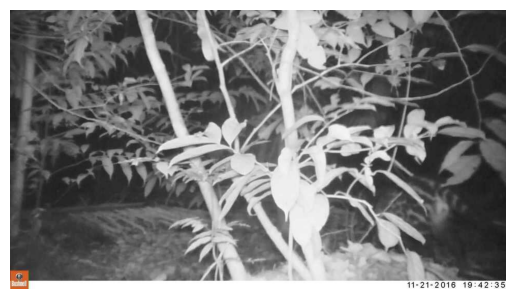

In [74]:
image_ext = os.path.join("dataset","test_features","ZJ016488.jpg")

image = PIL.Image.open(image_ext)

plt.imshow(image)
plt.axis("off");

In [76]:
torch.save(model.state_dict(), "wild_life_deepnet.pth")